# Project 2: Social Network Mining
ECE 232E Summer 2026   
Prof. Vwani Roychowdhury   
UCLA, Dept. of ECE 

Posted: Sunday, June 12, 2026  
Due: Sunday, July 26, 2026 at 11:59 PM PST

By Enoch Yeo 906630606 / Nicolas Jeong Lee 605309755 / James Chen 005399315

## 1. Facebook Network

### 1. Structural Properties of the Facebook Network

#### Question 1

In [1]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import random
import math

g = ig.Graph.Read_Edgelist("facebook_combined.txt", directed=False)

##### Question 1.1

In [2]:
print("Number of Nodes = ", g.vcount())
print("Number of Edges = ", g.ecount())

Number of Nodes =  4039
Number of Edges =  88234


##### Question 1.2

In [3]:
print("Connected = ", g.is_connected())

Connected =  True


#### Question 2

In [4]:
print("Diameter = ", g.diameter())

Diameter =  8


#### Question 3

Average Degree =  43.69101262688784
rough log-log slope: -1.1801644192508813


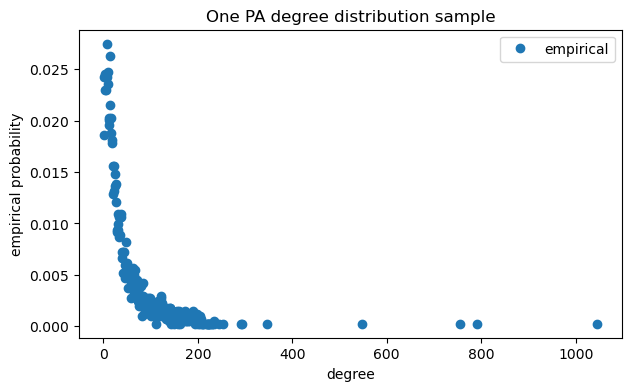

In [5]:
deg = np.asarray(g.degree())
print("Average Degree = ", sum(deg)/g.vcount())
k, counts = np.unique(deg, return_counts=True)
prob = counts / counts.sum()

mask = (k >= 1 ) & (counts > 0)
slope, intercept = np.polyfit(np.log(k[mask]), np.log(prob[mask]), 1)
print("rough log-log slope:", slope)

plt.figure(figsize=(7, 4))
plt.plot(k, prob, "o", label="empirical")
plt.legend()
plt.xlabel("degree")
plt.ylabel("empirical probability")
plt.title("One PA degree distribution sample")
plt.show()

#### Question 4

rough log-log slope: -1.1801644192508813


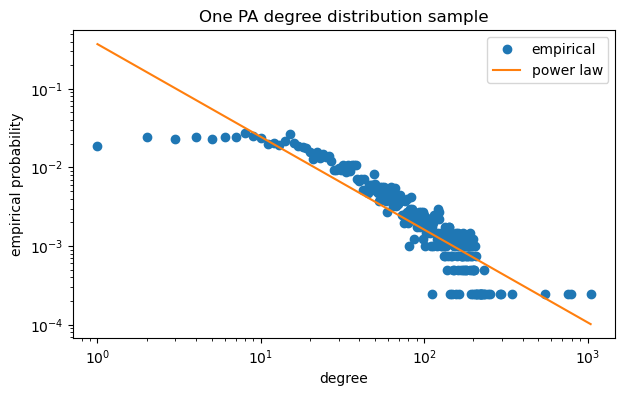

In [6]:
deg = np.asarray(g.degree())
k, counts = np.unique(deg, return_counts=True)
prob = counts / counts.sum()

mask = (k >= 1 ) & (counts > 0)
slope, intercept = np.polyfit(np.log(k[mask]), np.log(prob[mask]), 1)
print("rough log-log slope:", slope)

plt.figure(figsize=(7, 4))
plt.loglog(k, prob, "o", label="empirical")
plt.loglog(k, np.exp(intercept) * k**slope, label="power law")
plt.legend()
plt.xlabel("degree")
plt.ylabel("empirical probability")
plt.title("One PA degree distribution sample")
plt.show()

### 2. Personalized Network

#### Question 5

In [7]:
nodes = [0] + g.neighbors(0)
pn = g.induced_subgraph(nodes)
print("Number of Nodes = ", pn.vcount())
print("Number of Edges = ", pn.ecount())

Number of Nodes =  348
Number of Edges =  2866


#### Question 6

In [8]:
print("Diameter = ", pn.diameter())

Diameter =  2


Lower Bound: Every node in the Personalized Network is connected to $v_{i}$, so the distance between a node $u$ and $v_{i}$ is 1. Likewise, if two neighbors of $v_{i}$ are also connected, the distance between them is 1. Therefore, the diameter is at least 1.

Upper Bound: Since $v_{i}$ is connected to every neighbor, the distance between two of those neighbors is 2 since it has to go through $v_{i}$. Therefore, the diameter is at most 2.

#### Question 7

For the lower bound, it means that every single node are connected to each other and not just the node $v_{i}$. So the neighbors of node $v_{i}$ are also connected to each other. As a result, the distance between any node is 1. This is a fully connected network.

For the upper bound, there is at least one pair of neighbors of $v_{i}$ that are not connected to each other. So the network is not fully connected. Therefore, there are two nodes that, to get the distance between them, have to go through $v_{i}$.

### 3. Core node's personalized network

#### Question 8

In [9]:
count = 0
core_node = []
for node in range(0, g.vcount()):
    if len(g.neighbors(node)) > 200:  
        core_node.append(node)
        count += 1
print("Core Nodes = ", core_node)
print("Num of Core Nodes = ", count)

total_degree = 0
for node in core_node:
    total_degree += g.degree(node)
print("Average Degree of Core Nodes = ", total_degree / len(core_node))

Core Nodes =  [0, 107, 348, 483, 1086, 1199, 1352, 1431, 1584, 1589, 1663, 1684, 1730, 1746, 1768, 1800, 1827, 1888, 1912, 1941, 1985, 1993, 2047, 2078, 2123, 2142, 2206, 2218, 2229, 2233, 2240, 2266, 2347, 2410, 2464, 2507, 2543, 2560, 2611, 3437]
Num of Core Nodes =  40
Average Degree of Core Nodes =  279.375


### 3.1 Core node's personalized network

#### Question 9

In [10]:
def get_communities(g):
    results = {}

    # Fast-Greedy
    fg = g.community_fastgreedy()
    results["Fast-Greedy"] = fg.as_clustering()

    # Edge-Betweenness
    eb = g.community_edge_betweenness()
    results["Edge-Betweenness"] = eb.as_clustering()

    # Infomap
    results["Infomap"] = g.community_infomap()

    return results

def draw_network(pn, clustering, layout, ax, title):
    pal = ig.RainbowPalette(n=max(len(clustering), 2))
    ig.plot(
        clustering,
        target=ax,
        layout=layout,
        palette=pal,
        vertex_size=10,
        vertex_frame_width=0.3,
        edge_color="lightgray",
        edge_width=0.4
    )
    ax.set_title(title)
    ax.set_axis_off()

def plot_node(node_id):
    pn = g.induced_subgraph([node_id] + g.neighbors(node_id))
    layout = pn.layout("fr")
    results = get_communities(pn)

    print(f"Core Node ID {node_id + 1}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (name, cl) in zip(axes, results.items()):
        print(f"{name}: {len(cl)} Communities, Modularity = {cl.modularity:.4f}")
        draw_network(pn, cl, layout, ax, f"{name}\nModularity = {cl.modularity:.4f}")
    fig.suptitle(f"Core Node ID {node_id + 1}", fontsize=14)
    plt.tight_layout()
    plt.show()

Core Node ID 1
Fast-Greedy: 8 Communities, Modularity = 0.4131
Edge-Betweenness: 41 Communities, Modularity = 0.3533
Infomap: 24 Communities, Modularity = 0.3892


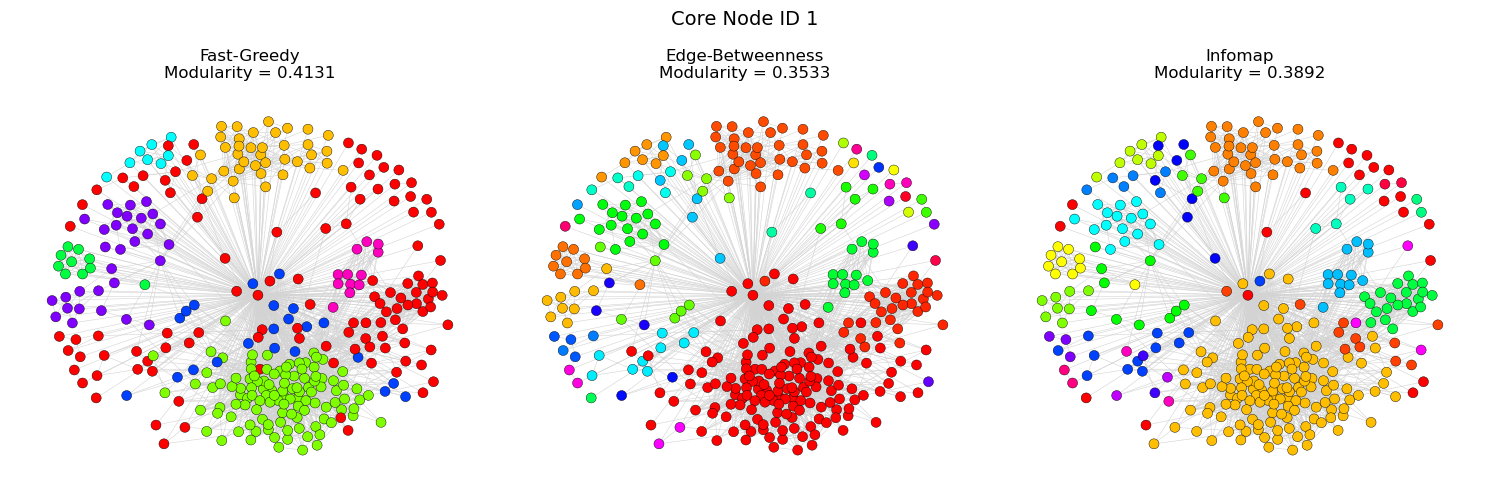

In [11]:
plot_node(0)

Core Node ID 108
Fast-Greedy: 9 Communities, Modularity = 0.4359
Edge-Betweenness: 52 Communities, Modularity = 0.5068
Infomap: 22 Communities, Modularity = 0.5085


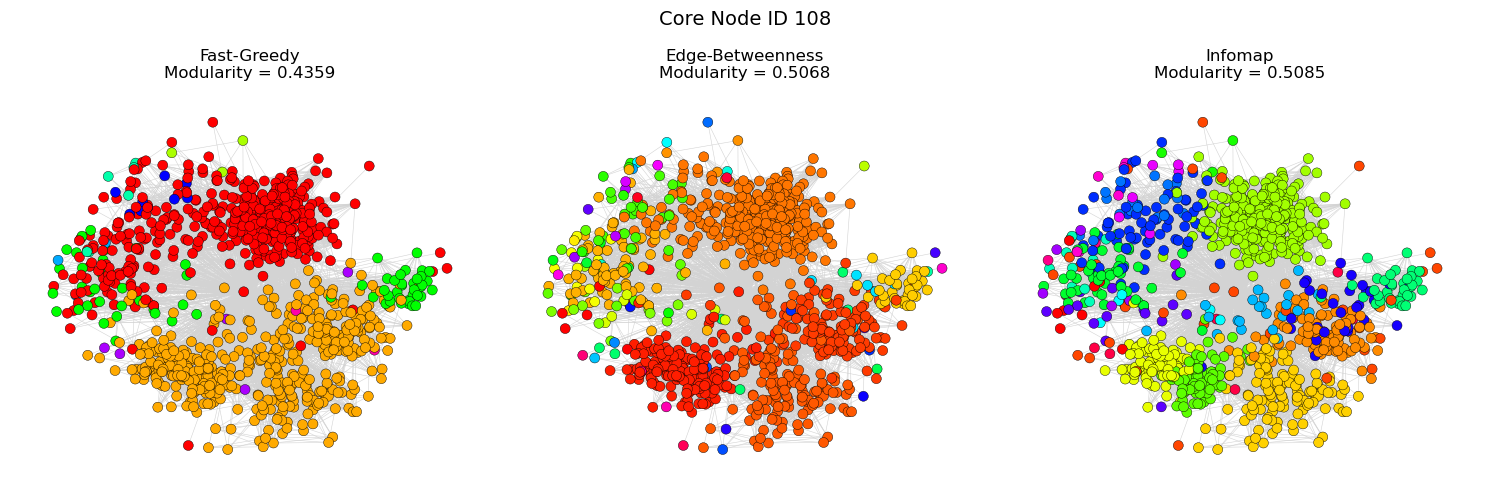

In [12]:
plot_node(107)

Core Node ID 349
Fast-Greedy: 5 Communities, Modularity = 0.2517
Edge-Betweenness: 104 Communities, Modularity = 0.1335
Infomap: 9 Communities, Modularity = 0.2168


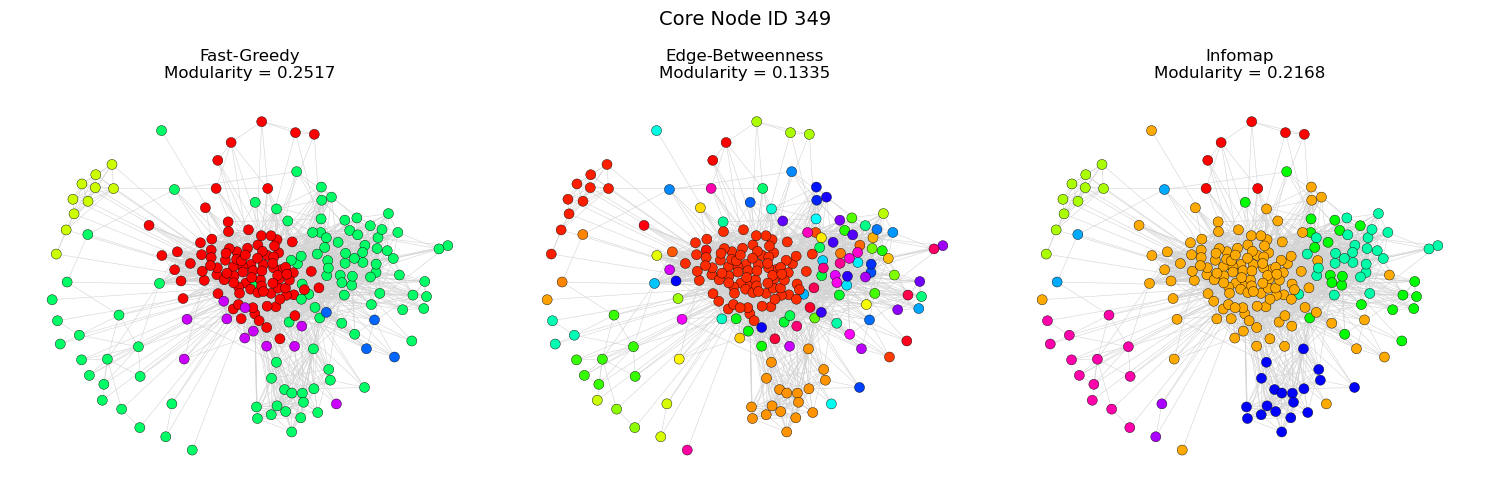

In [13]:
plot_node(348)

Core Node ID 484
Fast-Greedy: 3 Communities, Modularity = 0.5070
Edge-Betweenness: 10 Communities, Modularity = 0.4891
Infomap: 4 Communities, Modularity = 0.5153


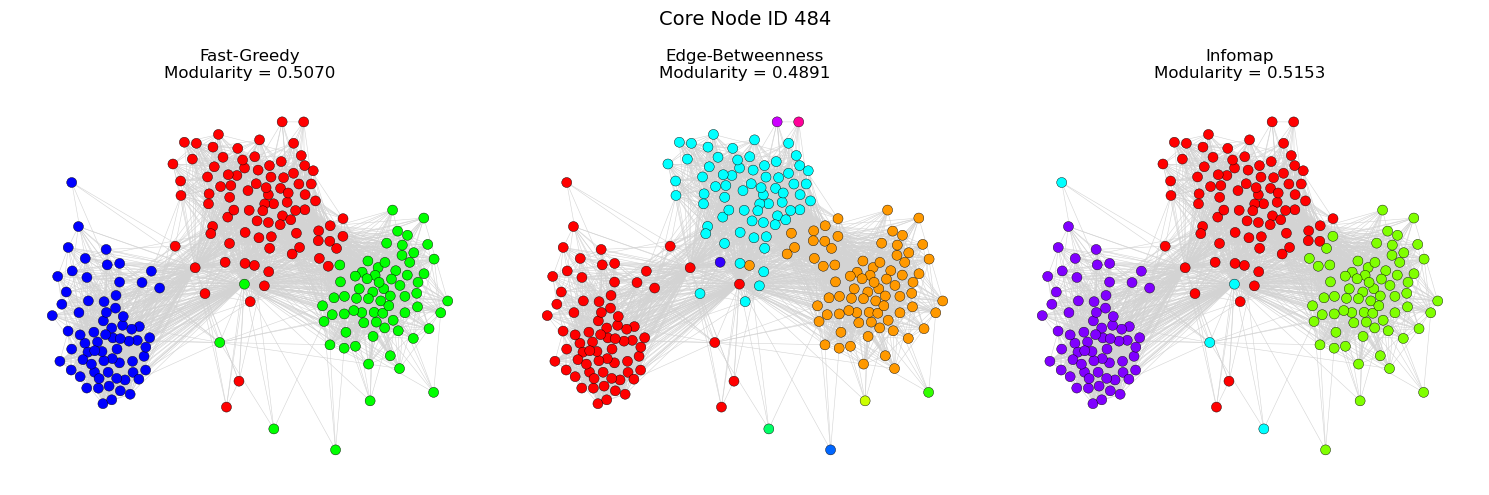

In [14]:
plot_node(483)

Core Node ID 1087
Fast-Greedy: 2 Communities, Modularity = 0.1455
Edge-Betweenness: 9 Communities, Modularity = 0.0276
Infomap: 4 Communities, Modularity = 0.0269


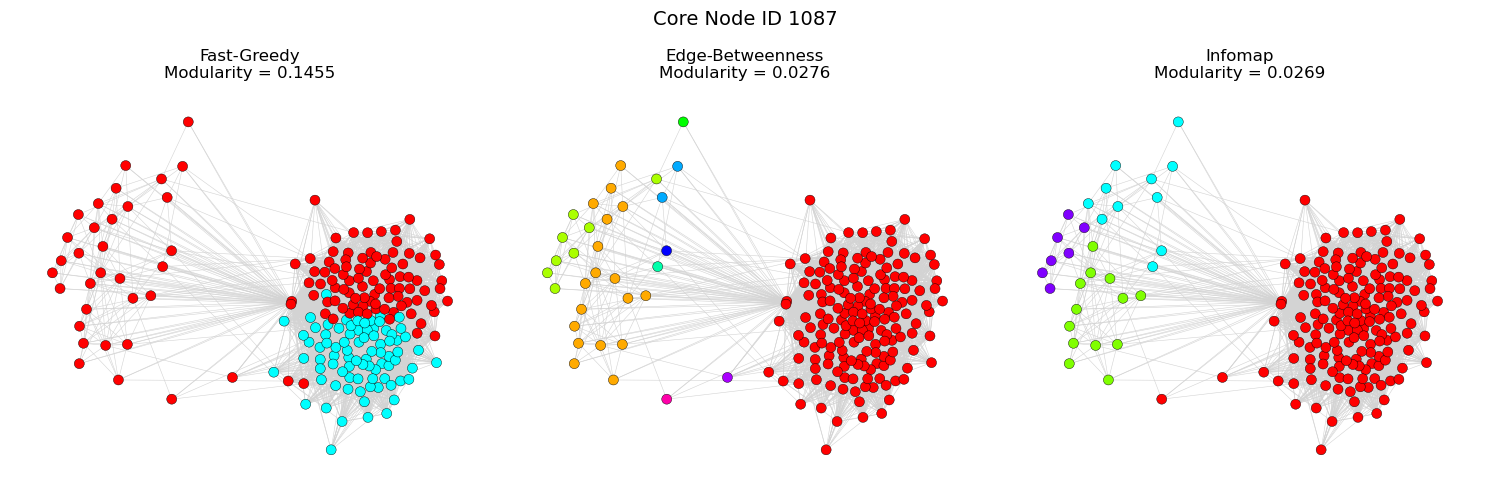

In [15]:
plot_node(1086)

### 3.2 Community Structure with the core node removed

#### Question 10

In [16]:
def plot_node_v2(node_id):
    pn = g.induced_subgraph([node_id] + g.neighbors(node_id))
    pn.delete_vertices(0)
    layout = pn.layout("fr").coords
    
    results = get_communities(pn)

    print(f"Core Node ID {node_id + 1} Deleted")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (name, cl) in zip(axes, results.items()):
        print(f"{name}: {len(cl)} Communities, Modularity = {cl.modularity:.4f}")
        draw_network(pn, cl, layout, ax, f"{name}\nModularity = {cl.modularity:.4f}")
    fig.suptitle(f"Core Node ID {node_id + 1} Deleted Modified Personalized Network", fontsize=14)
    plt.tight_layout()
    plt.show()

Core Node ID 1 Deleted
Fast-Greedy: 26 Communities, Modularity = 0.4419
Edge-Betweenness: 50 Communities, Modularity = 0.4161
Infomap: 36 Communities, Modularity = 0.4192


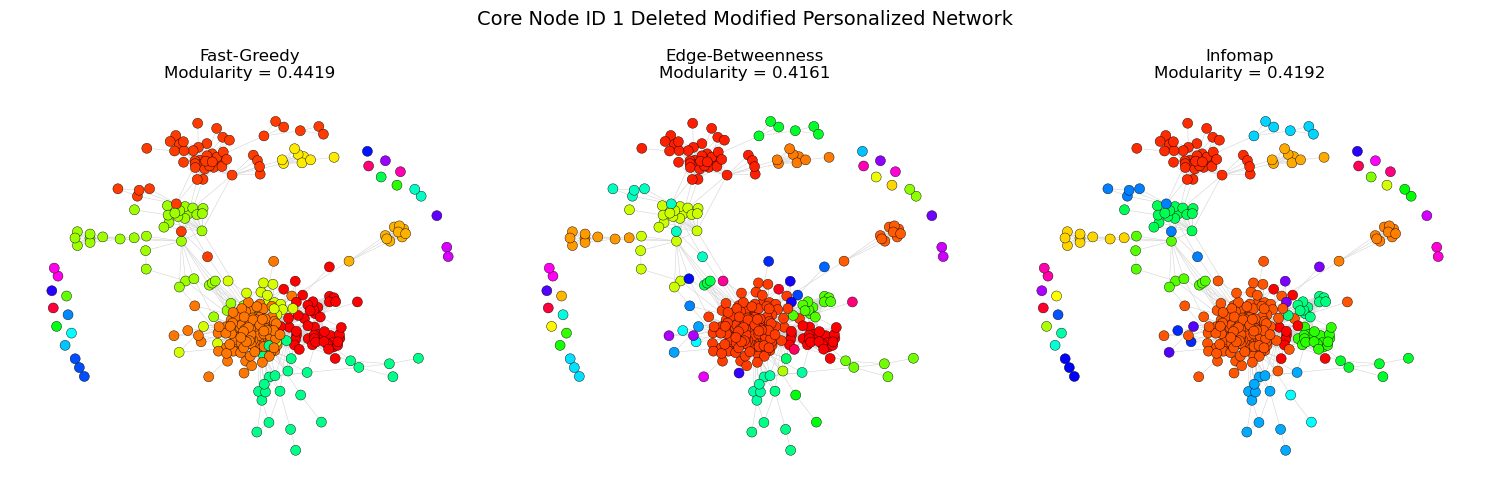

In [17]:
plot_node_v2(0)

Core Node ID 108 Deleted
Fast-Greedy: 9 Communities, Modularity = 0.4360
Edge-Betweenness: 52 Communities, Modularity = 0.5056
Infomap: 21 Communities, Modularity = 0.5093


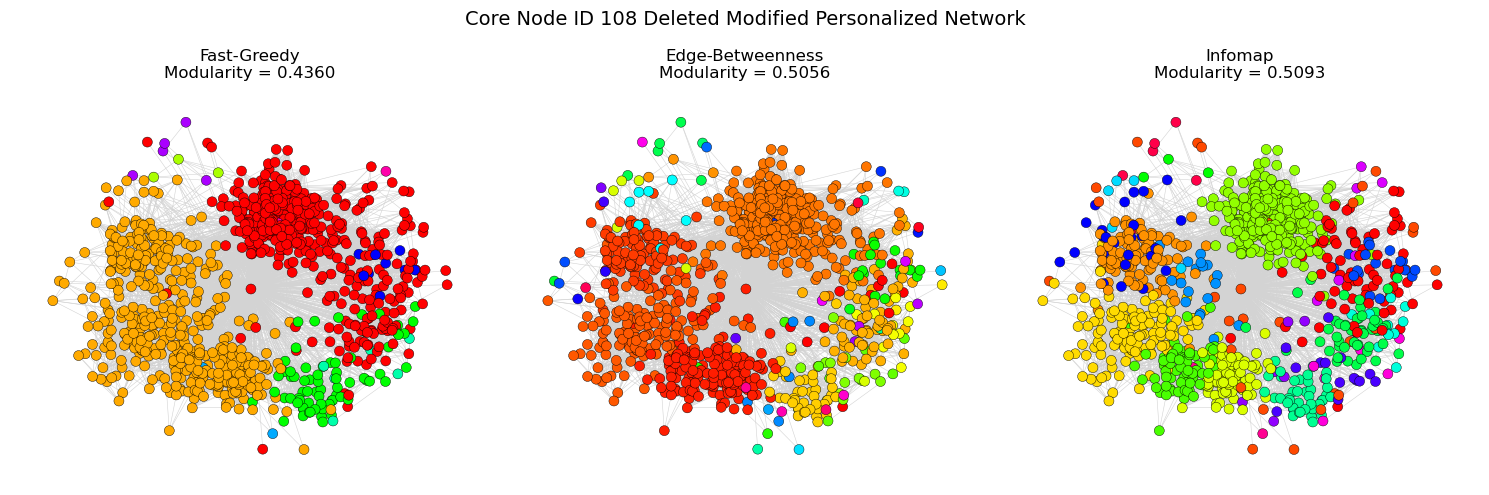

In [18]:
plot_node_v2(107)

Core Node ID 349 Deleted
Fast-Greedy: 5 Communities, Modularity = 0.2502
Edge-Betweenness: 103 Communities, Modularity = 0.1337
Infomap: 9 Communities, Modularity = 0.2171


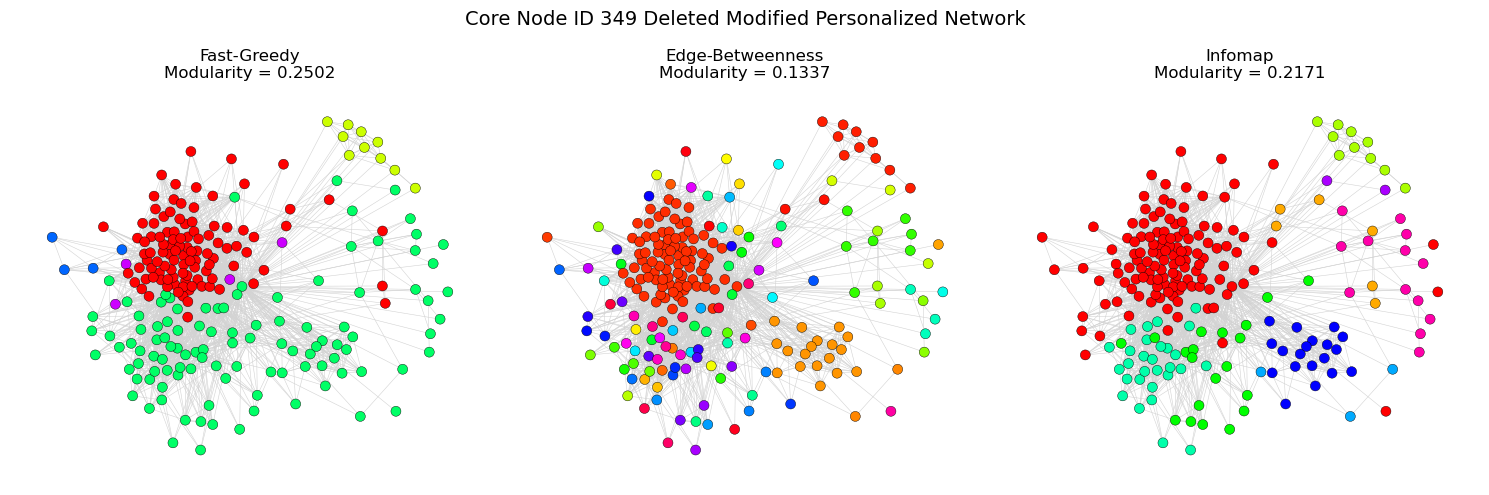

In [19]:
plot_node_v2(348)

Core Node ID 484 Deleted
Fast-Greedy: 3 Communities, Modularity = 0.5211
Edge-Betweenness: 13 Communities, Modularity = 0.4956
Infomap: 4 Communities, Modularity = 0.5292


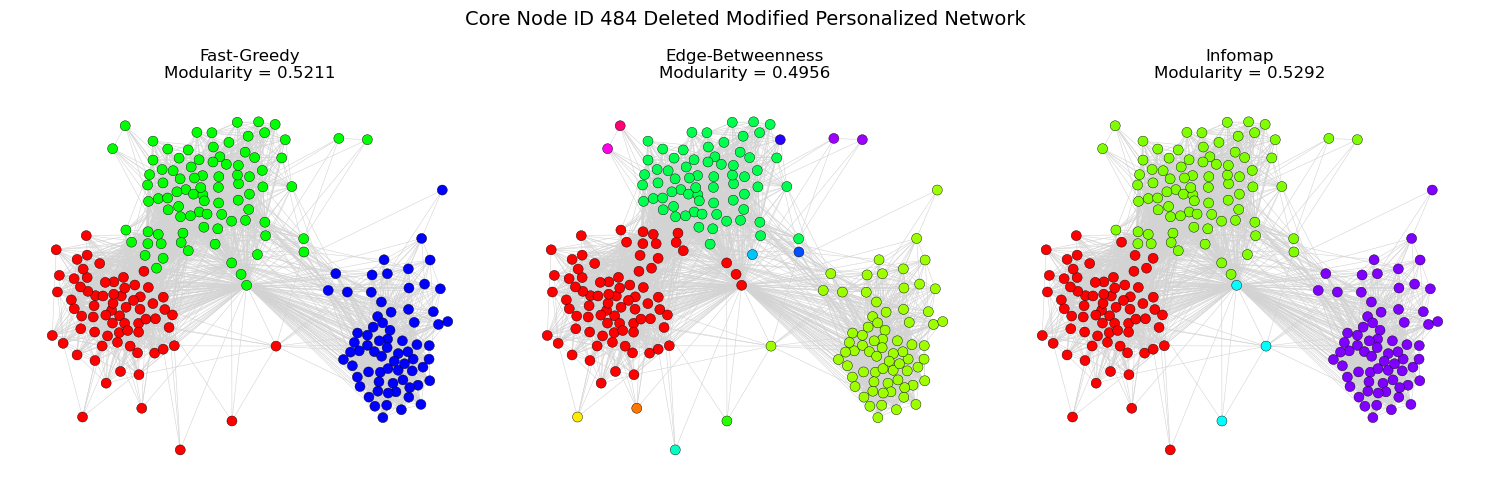

In [20]:
plot_node_v2(483)

Core Node ID 1088 Deleted
Fast-Greedy: 2 Communities, Modularity = 0.0799
Edge-Betweenness: 1 Communities, Modularity = 0.0000
Infomap: 1 Communities, Modularity = 0.0000


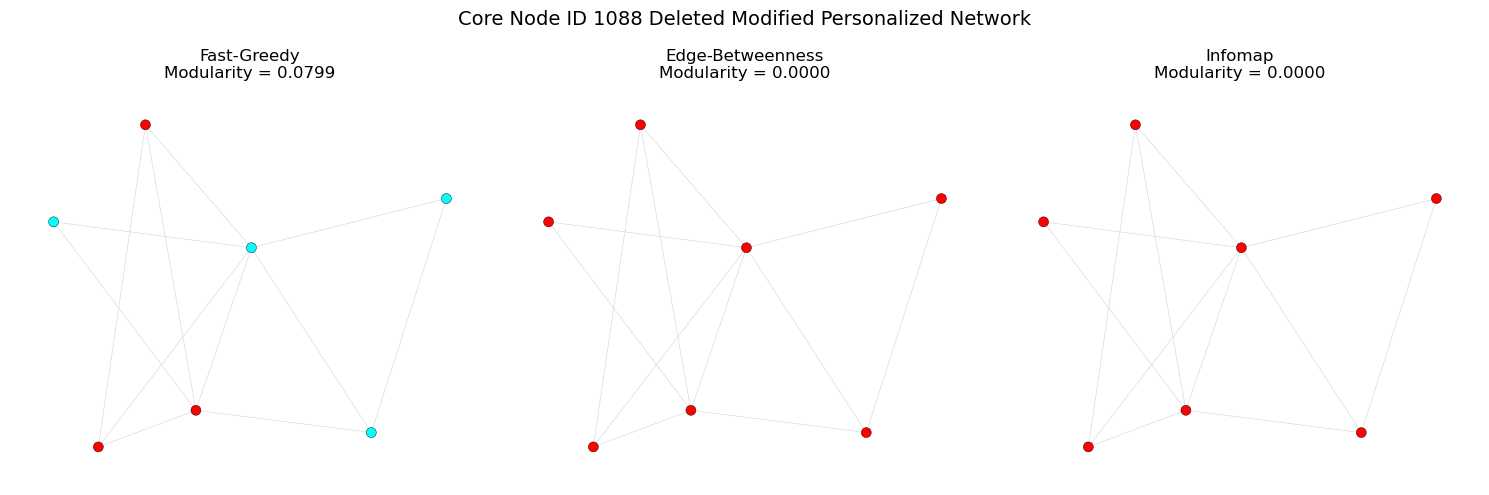

In [21]:
plot_node_v2(1087)

Comparing the Modularity from the Communities in Question 9 to those in Question 10, there wasn't a big difference in the change in modularity. In other words, the modularity score remained almost the same after removing the core node. This suggests there may be high internal redundancy with communities already exhibiting high connectedness, even with the removal of a core node.

### 3.3 Characteristic of nodes in the personalized network

#### Question 11

Embeddedness of a node is defined as the number of mutual friends a node shares with the core node.
Since a core node's personalized network is made up of the core node and all of the core node's neighbors, all of the neighbors of a non-core node are also neighbors of a core node (thus those are the mutual friends). In other words, the degree of non-core nodes can tell us about the embededness between a core node and non-core node.

More specifically, for a non-core node $v$ in core node's personalized network $PN$, we can define embededness between the core node and non-core node as:

$$Embededness(v) = deg(v) - 1 $$
We subtract one since we exclude the edge connecting $v$ and the core node (only interested in mutual friends).

#### Question 12

In [22]:
def embeddedness(pn, v, core=0):
    return pn.degree(v) - 1

def dispersion(pn, v, core=0):
    C = list(set(pn.neighbors(core)) & set(pn.neighbors(v)))
    if len(C) < 2: #If only one mutual or no mutuals then 
        return 0
    C_removed = [x for x in range(pn.vcount()) if x not in (core, v)] #Remove v and core node
    C_removed_pn = pn.induced_subgraph(C_removed) #Create modified network without v and core node

    #Remap the indices
    remap_idx = {old: new for new, old in enumerate(C_removed)}
    mutual_idx = [remap_idx[m] for m in C]

    #Get all mutual friends distances
    dist_mat = np.array(C_removed_pn.distances(source=mutual_idx, target=mutual_idx), dtype = float)
    dist_mat[np.isinf(dist_mat)] = 0 # Remove any nodes with no path between them(otherwise we have inf values)
    return dist_mat.sum() / 2  #dist_mat is symmetric so can sum the matrix and divide by 2(to avoid double count)

def q12_histogram(core):
    pn = g.induced_subgraph([core] + g.neighbors(core))
    others = [v for v in range(pn.vcount()) if v != 0]
    emb = [embeddedness(pn, v) for v in others]
    disp = [dispersion(pn, v) for v in others]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(emb, bins=30, color="steelblue", edgecolor="black")
    axes[0].set_title("Embeddedness Historgram"); axes[0].set_xlabel("Embeddedness")
    axes[0].set_ylabel("Count")
    axes[1].hist(disp, bins=30, color="indianred", edgecolor="black")
    axes[1].set_title("Dispersion Historgram"); axes[1].set_xlabel("Dispersion")
    fig.suptitle(f"Core Node ID {core + 1}", fontsize=14)
    plt.tight_layout(); plt.show()

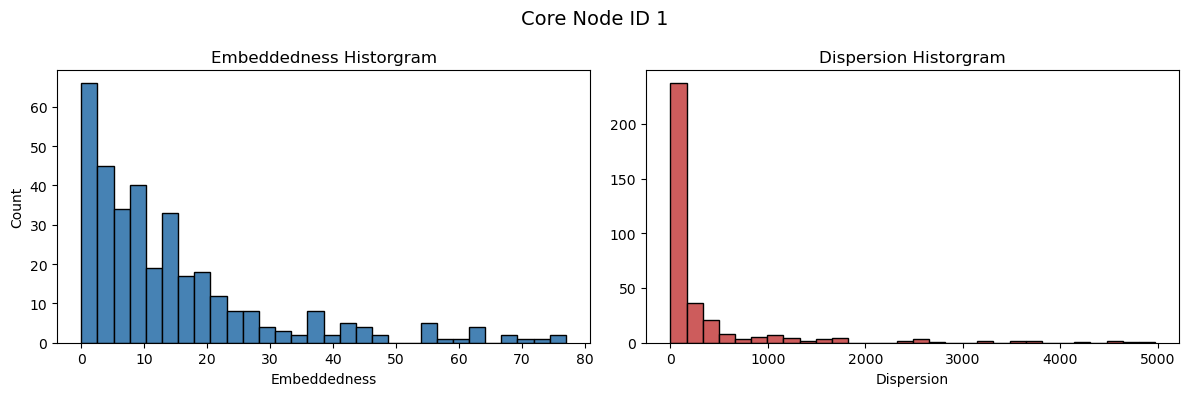

In [23]:
q12_histogram(0)

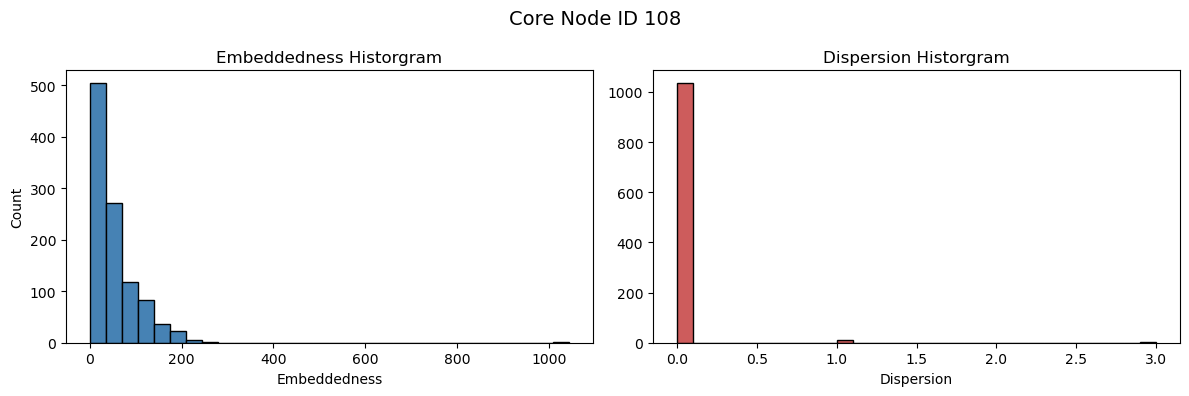

In [24]:
q12_histogram(107)

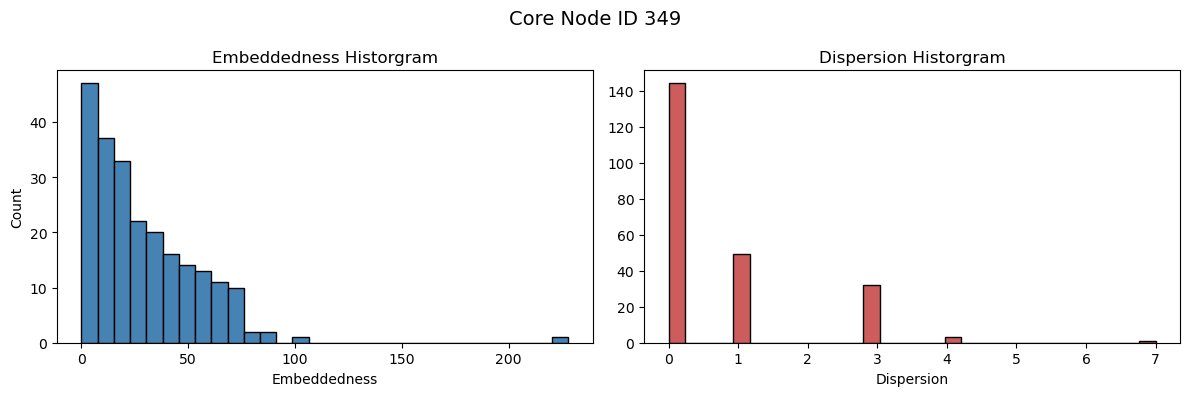

In [25]:
q12_histogram(348)

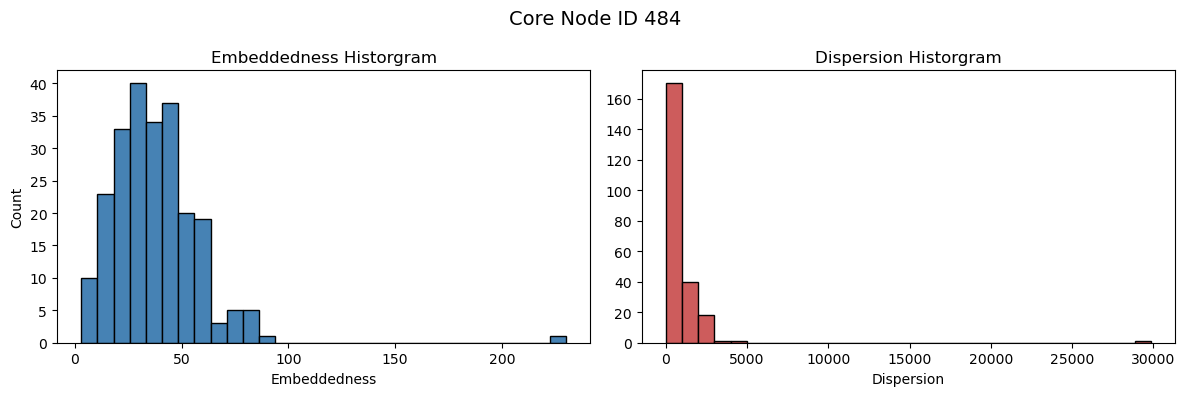

In [26]:
q12_histogram(483)

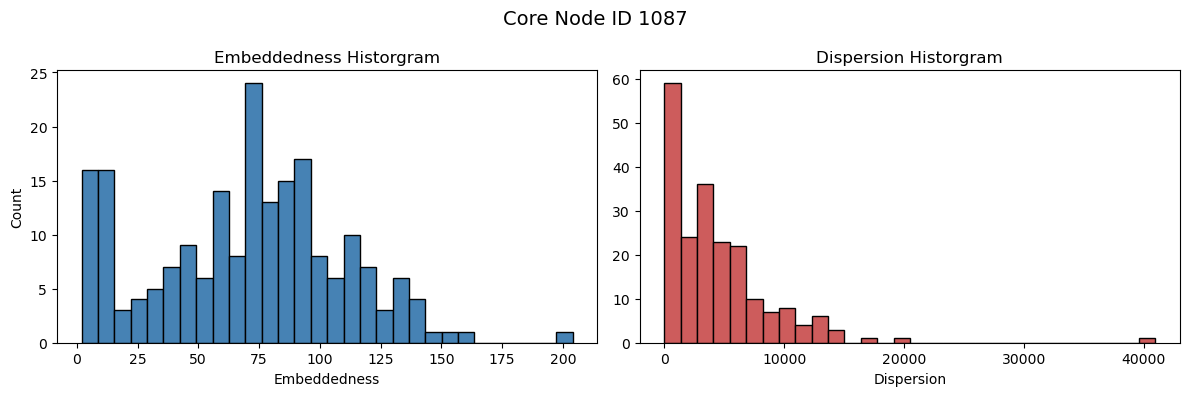

In [27]:
q12_histogram(1086)

#### Question 13

In [28]:
def highlight_draw_network(pn, clustering, layout, ax, title, highlights):
    pal = ig.RainbowPalette(n=max(len(clustering), 1))

    # Adds color to vertex based on the community they belong
    vcolors = [pal.get(m) for m in clustering.membership]
    vsizes  = [10] * pn.vcount()
    vshapes = ["circle"] * pn.vcount()
    for v, col in highlights.items(): #Forces the vertex based on highlights to be highlighted a specific color
        vcolors[v] = col
        vsizes[v]  = 32
        vshapes[v] = "diamond"

    # make all edges gray(make then shorter width) but force edges incident to highlighted node to be highlighted too(have longer width too)
    ecolors, ewidths = [], []
    for e in pn.es:
        col = highlights.get(e.source) or highlights.get(e.target)
        ecolors.append(col if col else "lightgray")
        ewidths.append(1.6 if col else 0.3)

    ig.plot(
        pn,                         
        target=ax,
        layout=layout,
        vertex_color=vcolors,
        vertex_size=vsizes,
        vertex_shape=vshapes,
        vertex_frame_width=0.3,
        edge_color=ecolors,
        edge_width=ewidths
    )
    ax.set_title(title)
    ax.set_axis_off()

def q13_plot(core):
    nodes = [core] + g.neighbors(core)
    pn = g.induced_subgraph(nodes)
    layout = pn.layout("fr")
    fg = pn.community_fastgreedy().as_clustering()

    others = [v for v in range(pn.vcount()) if v != 0] #Get all non-core nodes
    disp = {v: dispersion(pn, v) for v in others}
    max_disp = max(disp, key=disp.get)
    print(f"Core Node {core + 1}: Max Dispersion Node = "f"{nodes[max_disp] + 1} (Dispersion = {disp[max_disp]})")

    fig, ax = plt.subplots(figsize=(7, 7))
    highlight_draw_network(pn, fg, layout, ax, f"Core Node {core + 1} — Max Dispersion Highlighted", {max_disp: "black"})
    plt.tight_layout(); plt.show()

In the following plots, the node with maximum dispersion is highlighted in black.

Core Node 1: Max Dispersion Node = 57 (Dispersion = 4971.0)


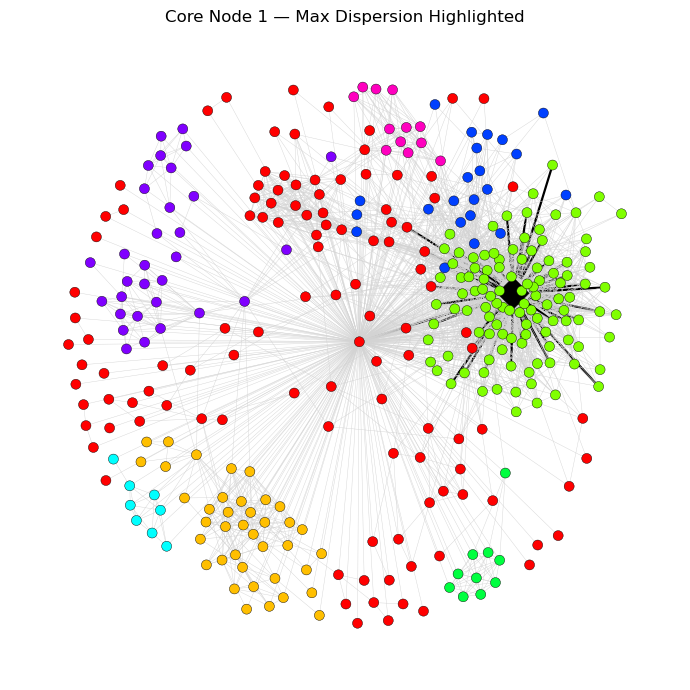

In [29]:
q13_plot(0)

Core Node 108: Max Dispersion Node = 1685 (Dispersion = 3.0)


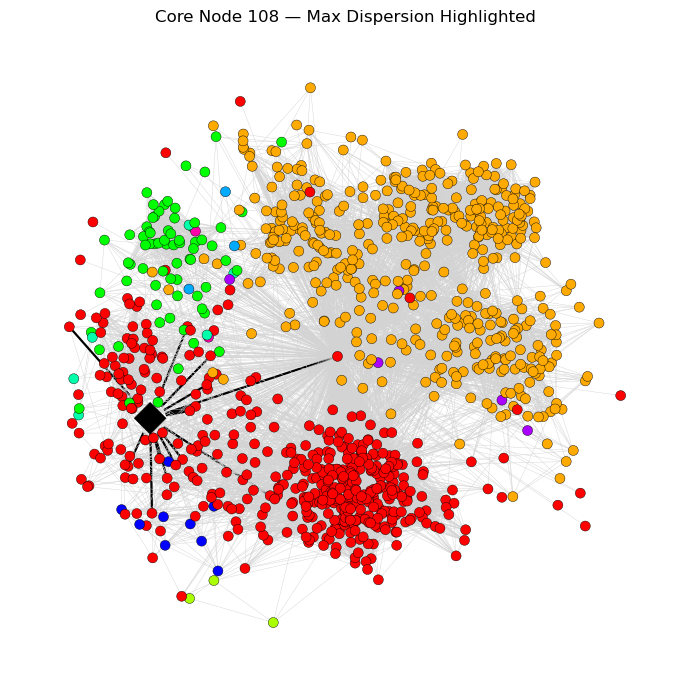

In [30]:
q13_plot(107)

Core Node 349: Max Dispersion Node = 428 (Dispersion = 7.0)


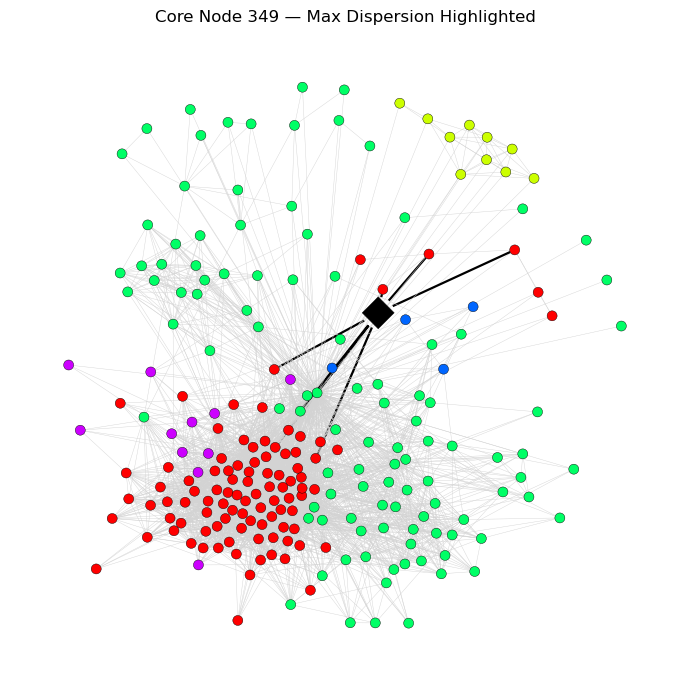

In [31]:
q13_plot(348)

Core Node 484: Max Dispersion Node = 483 (Dispersion = 29837.0)


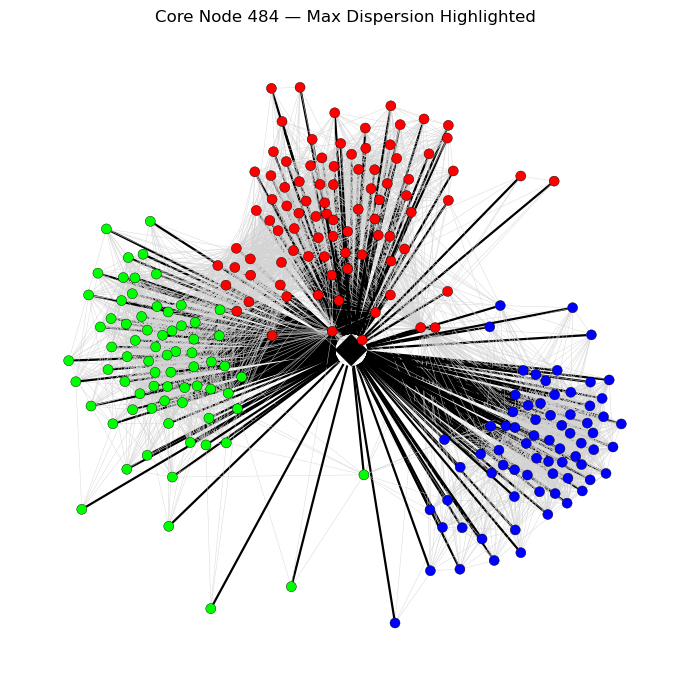

In [32]:
q13_plot(483)

Core Node 1087: Max Dispersion Node = 1084 (Dispersion = 40969.0)


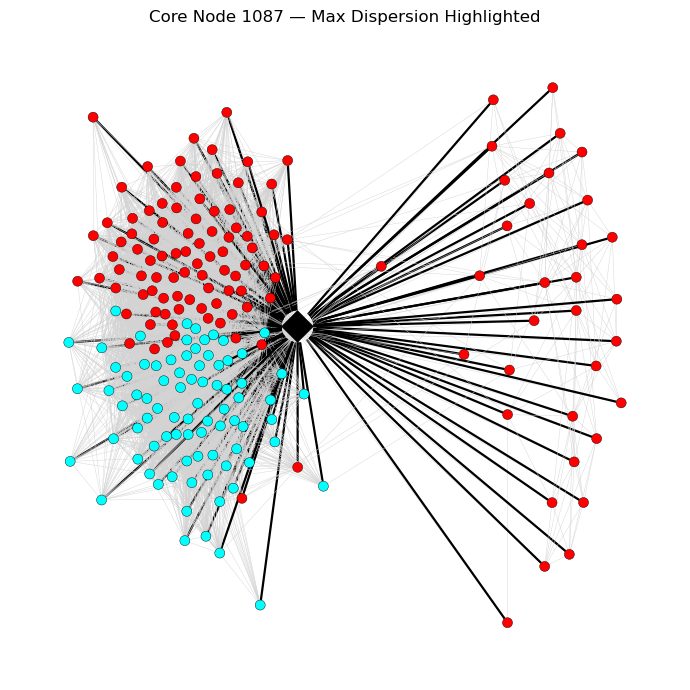

In [33]:
q13_plot(1086)

#### Question 14

In [34]:
def q14_plot(core):
    nodes = [core] + g.neighbors(core)
    pn = g.induced_subgraph(nodes)
    layout = pn.layout("fr")
    fg = pn.community_fastgreedy().as_clustering()

    others = [v for v in range(pn.vcount()) if v != 0] #Get all non-core nodes
    emb  = {v: embeddedness(pn, v) for v in others}
    disp = {v: dispersion(pn, v) for v in others}

    zero_emb = [v for v in others if emb[v] > 0] # exclude zero embeddedness
    max_emb   = max(zero_emb, key=lambda v: emb[v])
    max_ratio = max(zero_emb, key=lambda v: disp[v] / emb[v])

    print(f"Core Node {core + 1}:")
    print(f"Max Embeddedness Node = {nodes[max_emb] + 1} "f"(Embeddedness = {emb[max_emb]})")
    print(f"Max Dispersion/Embeddedness Node = {nodes[max_ratio] + 1} "f"(ratio = {disp[max_ratio]/emb[max_ratio]})")
    if nodes[max_emb] == nodes[max_ratio]:
        print("Max Embeddedness Node and Max Dispersion/Embeddedness Node are the same for this Core Node's Personalized Network")
    
    fig, ax = plt.subplots(figsize=(7, 7))
    highlight_draw_network(pn, fg, layout, ax, f"Core Node {core + 1} — Max Embeddedness (black) "f"& Max Dispersion/Embeddednes (yellow)", {max_emb: "black", max_ratio: "yellow"})
    plt.tight_layout(); plt.show()

Core Node 1:
Max Embeddedness Node = 57 (Embeddedness = 77)
Max Dispersion/Embeddedness Node = 26 (ratio = 66.22058823529412)


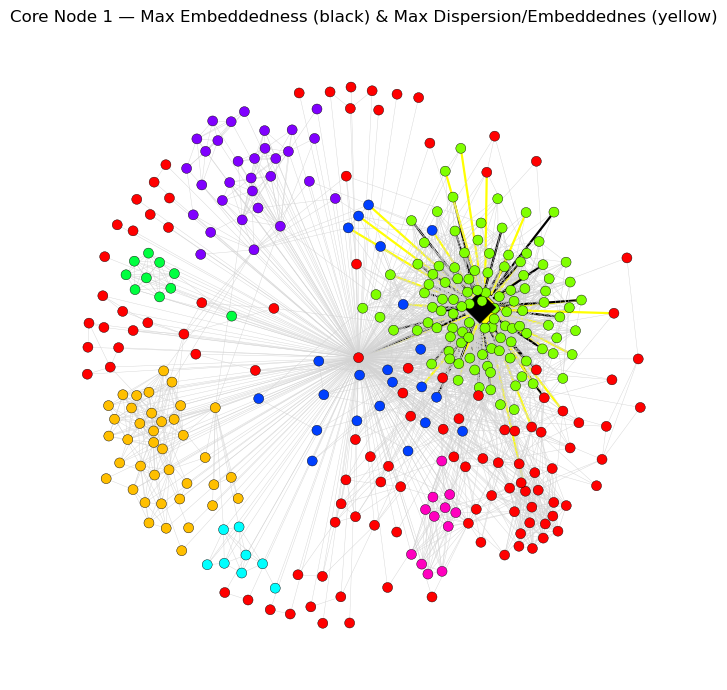

In [35]:
q14_plot(0)

Core Node 108:
Max Embeddedness Node = 59 (Embeddedness = 1044)
Max Dispersion/Embeddedness Node = 905 (ratio = 0.5)


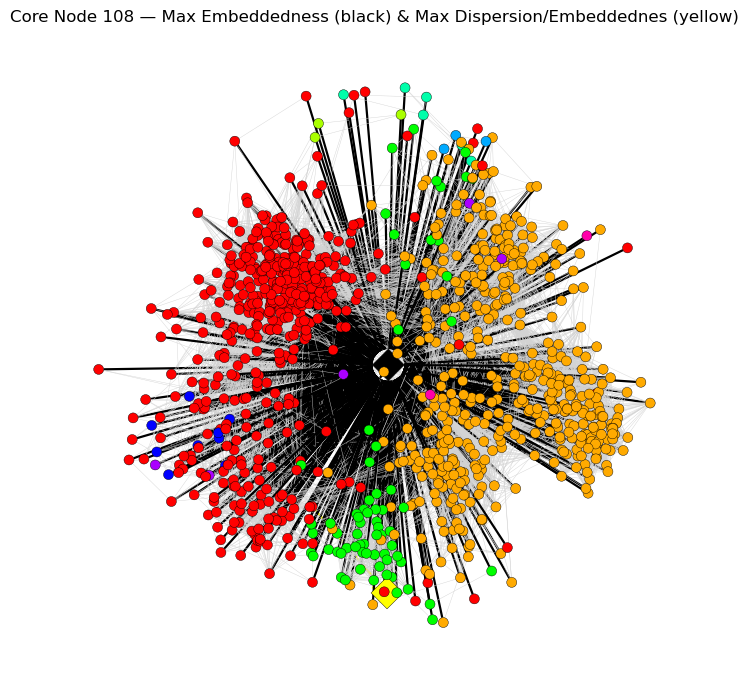

In [36]:
q14_plot(107)

Core Node 349:
Max Embeddedness Node = 199 (Embeddedness = 228)
Max Dispersion/Embeddedness Node = 428 (ratio = 0.875)


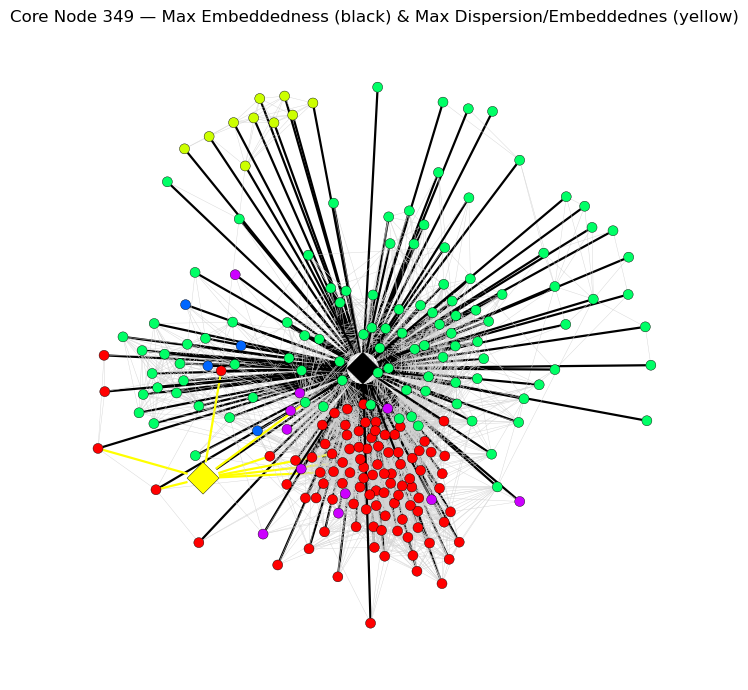

In [37]:
q14_plot(348)

Core Node 484:
Max Embeddedness Node = 483 (Embeddedness = 230)
Max Dispersion/Embeddedness Node = 483 (ratio = 129.72608695652173)
Max Embeddedness Node and Max Dispersion/Embeddedness Node are the same for this Core Node's Personalized Network


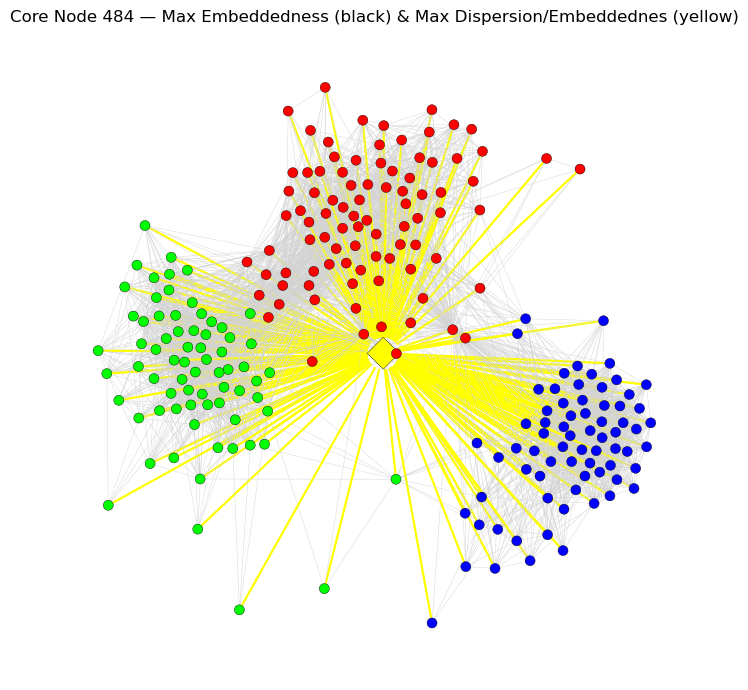

In [38]:
q14_plot(483)

Core Node 1087:
Max Embeddedness Node = 1084 (Embeddedness = 204)
Max Dispersion/Embeddedness Node = 1084 (ratio = 200.82843137254903)
Max Embeddedness Node and Max Dispersion/Embeddedness Node are the same for this Core Node's Personalized Network


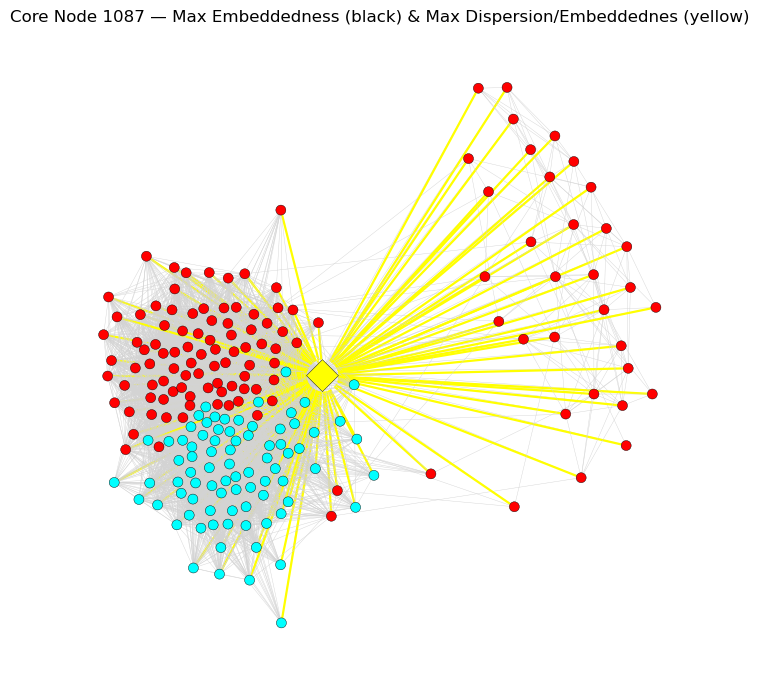

In [39]:
q14_plot(1086)

#### Question 15

For the Max Embeddedness node, either of two scenarios happen: they are inside one dense community and its incident edges stay almost entirely within that one community (like Core Node 1) or the node is right in the middle of the network with edges to almost all nodes around it (like the rest of the core nodes_. So embeddedness reveals how central a node is inside one cohesive group. The biggest cluster tends to contain the most embedded node because there are more "mutual friends" there.

For dispersion, a high-dispersion node is one where the common neighbors of that node and the core node are not well connected to each other. After you remove those two nodes from the graph, those common neighbors end up far apart. A low-dispersion node is the opposite.

Dispersion/Embeddedness combines both: It is high when the "mutual friends" are spread far apart (high dispersion) relative to how many "mutual friends" there are (embeddedness).

### 4. Friend Recommendation in Personalized Networks

In [40]:
pn_415 = g.induced_subgraph([414] + g.neighbors(414))

#### Question 16

In [41]:
nodes_degree_24 = pn_415.vs.select(_degree=24)
Nr = [v.index for v in nodes_degree_24]
print("|N_r| = ",len(Nr))
print(Nr)

|N_r| =  11
[30, 52, 74, 89, 92, 101, 117, 132, 133, 135, 136]


#### Question 17

In [42]:
def neighborhood_measure(pn, measure):
    if measure == "common":
        A = np.array(pn.get_adjacency().data)
        return A @ A
    if measure == "jaccard":
        return np.array(pn.similarity_jaccard())
    if measure == "adamic":
        return np.array(pn.similarity_inverse_log_weighted())
    raise ValueError(measure)

def avg_accuracy(pn, Nr, measure, trials=10, p=0.25, seed=0):
    rng = random.Random(seed)
    
    all_Nr_accuracies = []
    for user_i in Nr:
        accuracies = []
        for trial in range(trials):
            pn_copy = pn.copy() # Make a copy since we will remove edges from node i at random

            # 1. Remove each edge of node i with prob 0.25
            remove_edges = [edge for edge in pn_copy.incident(user_i) if rng.random() < p]
            if not remove_edges:
                continue
            R_i = set() # Create the list of friends deleted Ri (if there are no edges removed, Ri is empty)
            for edge in remove_edges:
                edge_sequence = pn_copy.es[edge]
                if edge_sequence.source == user_i: #Makes sure user i is not deleted, but the node connecting to i
                    R_i.add(edge_sequence.target)
                else:
                    R_i.add(edge_sequence.source)
            pn_copy.delete_edges(remove_edges)

            # 2. Recommend |R_i| new friends to user i
            score = neighborhood_measure(pn_copy, measure)[user_i] #Neighborhood_measure returns a matrix, [user_i] gets you the ith row

            neighbors_after_removal = set(pn_copy.neighbors(user_i)) #Get the neighbors after removing edges
            recommend = [j for j in range(pn_copy.vcount()) if j != user_i and j not in neighbors_after_removal] # Get the possible candidates
            recommend.sort(key=lambda j: score[j], reverse=True) #Sort friends based on highest measure/score
            P_i = set(recommend[:len(R_i)]) # Get P_i; list of friends recommended

            # 3. Compute accuracies
            accuracies.append(len(P_i & R_i) / len(R_i))
        if accuracies: # Just in case R_i is empty
            all_Nr_accuracies.append(sum(accuracies) / len(accuracies))
    return sum(all_Nr_accuracies) / len(all_Nr_accuracies)

In [43]:
print("Common Neighbors Average Accuracy = ", avg_accuracy(pn_415, Nr, "common"))

Common Neighbors Average Accuracy =  0.8157523284796011


In [44]:
print("Jaccard Average Accuracy = ", avg_accuracy(pn_415, Nr, "jaccard"))

Jaccard Average Accuracy =  0.798429970702698


In [45]:
print("Adamic Adar Average Accuracy = ", avg_accuracy(pn_415, Nr, "adamic"))

Adamic Adar Average Accuracy =  0.8216614193886922


Adamic Adar Measure had the highest accuracy; thus, the best friend recommendation algorithm